In [1]:
%load_ext autoreload
%autoreload 2

import hea
import polars as pl
import matplotlib.pyplot as plt

from hea import lm, col, data, factor
from hea.compare import AIC, anova

## Examples from *Linear Models with R* (Faraway, 2014)

### 1.2

In [2]:
pima = data("pima")
pima.head()

pregnant,glucose,diastolic,triceps,insulin,bmi,diabetes,age,test
i64,i64,i64,i64,i64,f64,f64,i64,i64
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1


In [3]:
pima = pima.mutate(
    col("diastolic", "glucose", "triceps", "insulin", "bmi").replace(0, None),
    test = factor(col("test"), labels={0: "negative", 1: "positive"})
)
pima.summary()

   pregnant        glucose       diastolic        triceps        insulin
Min.   : 0.000  Min.   : 44.0  Min.   : 24.00  Min.   : 7.00  Min.   : 14.00
1st Qu.: 1.000  1st Qu.: 99.0  1st Qu.: 64.00  1st Qu.:22.00  1st Qu.: 76.25
Median : 3.000  Median :117.0  Median : 72.00  Median :29.00  Median :125.00
Mean   : 3.845  Mean   :121.7  Mean   : 72.41  Mean   :29.15  Mean   :155.55
3rd Qu.: 6.000  3rd Qu.:141.0  3rd Qu.: 80.00  3rd Qu.:36.00  3rd Qu.:190.00
Max.   :17.000  Max.   :199.0  Max.   :122.00  Max.   :99.00  Max.   :846.00
                NA's   :    5  NA's   :    35  NA's   :  227  NA's   :   374

     bmi          diabetes           age           test
Min.   :18.20  Min.   :0.07800  Min.   :21.00  negative:500
1st Qu.:27.50  1st Qu.:0.24375  1st Qu.:24.00  positive:268
Median :32.30  Median :0.37250  Median :29.00
Mean   :32.46  Mean   :0.47188  Mean   :33.24
3rd Qu.:36.60  3rd Qu.:0.62625  3rd Qu.:41.00
Max.   :67.10  Max.   :2.42000  Max.   :81.00
NA's   :   11

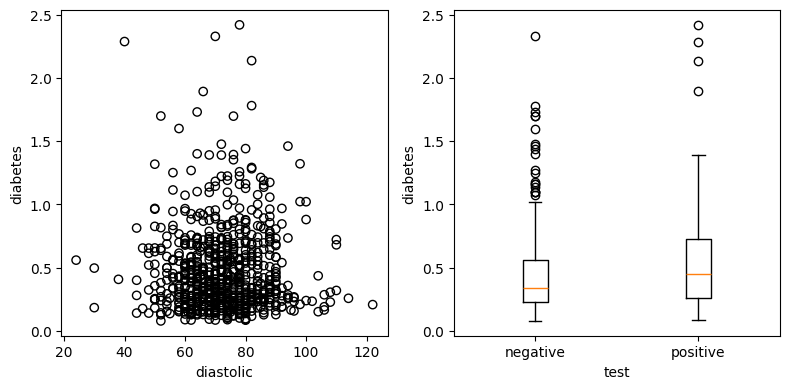

In [4]:
from hea.plot import plot

fig, ax = plt.subplot_mosaic(
    [["scatter", "boxplot"]],
    figsize=(8, 4),
)

p1 = plot("diabetes ~ diastolic", pima, ax=ax["scatter"])
p2 = plot("diabetes ~ test", pima, ax=ax["boxplot"])

fig.tight_layout()

/Users/ziweih/Works/hea/hea/ggplot/_block.py:846: UserWarning: Removed 35 rows containing missing values (`geom_bar()`).
  cells[r][c] = (child, compute_block(child))
/Users/ziweih/Works/hea/hea/ggplot/_block.py:846: UserWarning: Removed 35 rows containing missing values (`geom_density()`).
  cells[r][c] = (child, compute_block(child))
/Users/ziweih/Works/hea/hea/ggplot/_block.py:846: UserWarning: Removed 35 rows containing missing values (`geom_point()`).
  cells[r][c] = (child, compute_block(child))


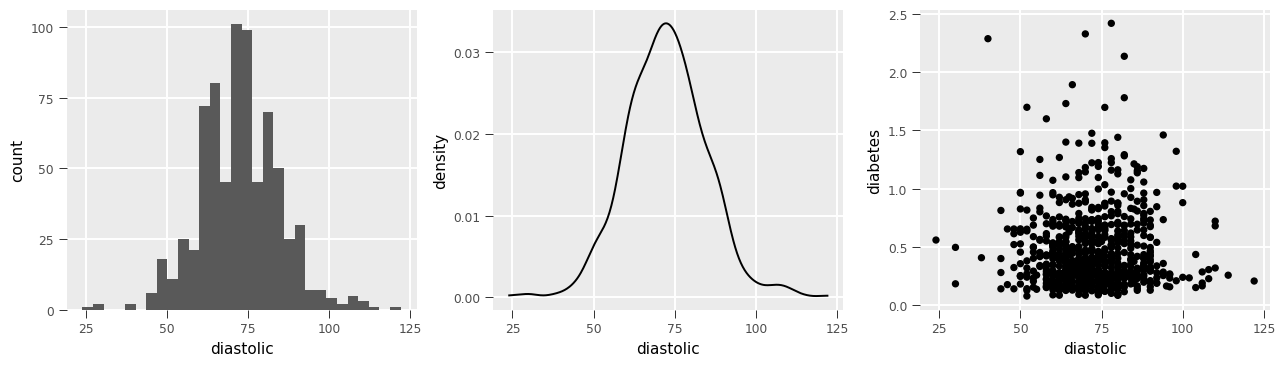

In [5]:
from hea.ggplot import aes

p1 = pima.ggplot(aes(x="diastolic")).geom_histogram()
p2 = pima.ggplot(aes(x="diastolic")).geom_density()
p3 = pima.ggplot(aes(x="diastolic", y="diabetes")).geom_point()

p1 | p2 | p3

/Users/ziweih/Works/hea/hea/ggplot/_block.py:846: UserWarning: Removed 35 rows containing missing values (`geom_point()`).
  cells[r][c] = (child, compute_block(child))


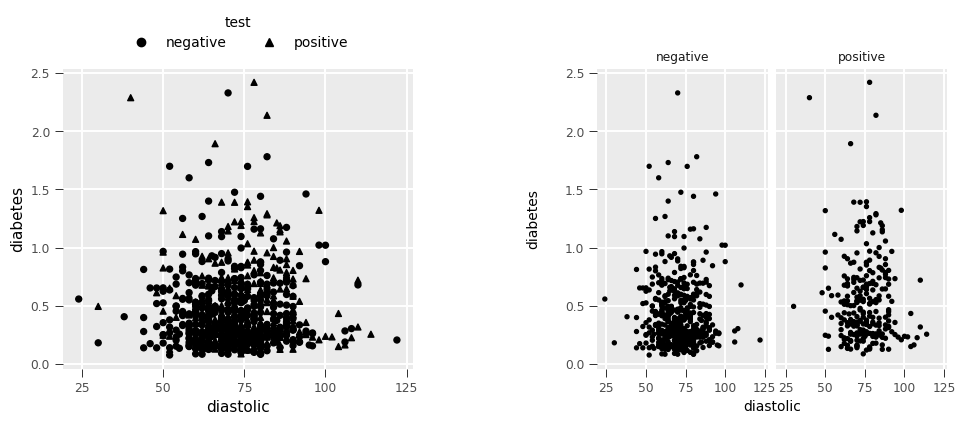

In [6]:
from hea.ggplot import theme, plot_layout
p1 = (
    pima.ggplot(aes(x="diastolic", y="diabetes", shape="test"))
        .geom_point()
        + theme(legend_position="top", legend_direction="horizontal")
)
p2 = (
    pima.ggplot(aes(x="diastolic", y="diabetes"))
        .geom_point(size=1)
        .facet_grid("~ test")
)

(p1 + p2)

### 1.4

In [7]:
manilius = data("manilius")
manilius.head()

arc,sinang,cosang,group
f64,f64,f64,i64
13.166667,0.8836,-0.4682,1
13.133333,0.9996,-0.0282,1
13.2,0.9899,0.1421,1
14.25,0.2221,0.975,3
14.7,0.0006,1.0,3


In [8]:
m1 = lm('arc ~ sinang + cosang', manilius)
m1.coef

(Intercept),sinang,cosang
f64,f64,f64
14.561624,-1.504581,0.091365


<Axes: xlabel='midparentHeight', ylabel='childHeight'>

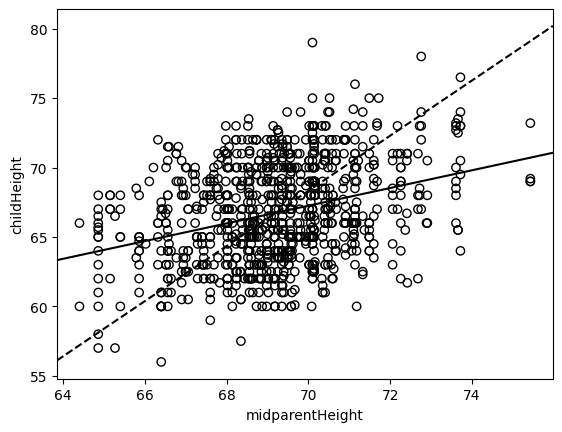

In [9]:
from hea.plot import abline

GaltonFamilies = data("GaltonFamilies")

beta1 = GaltonFamilies["childHeight"].std() / GaltonFamilies["midparentHeight"].std()
alpha1 = GaltonFamilies["childHeight"].mean() - beta1 * GaltonFamilies["midparentHeight"].mean()

m2 = lm('childHeight ~ midparentHeight', GaltonFamilies)

ax = plot('childHeight ~ midparentHeight', GaltonFamilies)
abline(alpha1, beta1, lty=2, ax=ax)
abline(m2, ax=ax)

### 2.6

In [10]:
gala = data('gala', package='faraway')
m0 = lm('Species ~ Area + Elevation + Nearest + Scruz + Adjacent', gala)
m0.summary()

Formula: Species ~ Area + Elevation + Nearest + Scruz + Adjacent

Residuals:
     Min      1Q Median     3Q     Max
-111.679 -34.898 -7.862 33.460 182.584

Coefficients:
              Estimate  Std. Error   CI[2.5%]  CI[97.5]%    t value  Pr(>|t|)
(Intercept)   7.068221   19.154198  -32.46410   46.60054   0.369017  0.715351
Area         -0.023938    0.022422   -0.07022    0.02234  -1.067611  0.296318
Elevation     0.319465    0.053663    0.20871    0.43022   5.953188  3.82e-06  ***
Nearest       0.009144    1.054136   -2.16649    2.18477   0.008674  0.993151
Scruz        -0.240524    0.215402   -0.68509    0.20404  -1.116628  0.275208
Adjacent     -0.074805    0.017700   -0.11134   -0.03827  -4.226217  0.000297  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 30, p = 6, Residual SE = 60.975 on 24 DF
R-Squared = 0.7658, adjusted R-Squared = 0.7171
F-statistics = 15.6994 on 5 and 24 DF, p-value: 6.837893e-07

Log Likelihood = -162.5350, AIC = 339.0700, BIC = 34

### 2.10

In [11]:
odor = data('odor', package='faraway')
m1 = lm('odor ~ temp + gas + pack', odor)
m1.summary(cor=True)

Formula: odor ~ temp + gas + pack

Residuals:
    Min      1Q Median     3Q    Max
-50.200 -17.137  1.175 20.300 62.925

Coefficients:
             Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)    15.200       9.298    -5.265     35.665   1.6347     0.130
temp          -12.125      12.732   -40.148     15.898  -0.9523     0.361
gas           -17.000      12.732   -45.023     11.023  -1.3352     0.209
pack          -21.375      12.732   -49.398      6.648  -1.6788     0.121
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 4, Residual SE = 36.012 on 11 DF
R-Squared = 0.3337, adjusted R-Squared = 0.1519
F-statistics = 1.8361 on 3 and 11 DF, p-value: 0.20

Log Likelihood = -72.7155, AIC = 155.4310, BIC = 158.9713

Correlation of Coefficients:
     (Intercept) temp gas
temp 0.00
gas  0.00        0.00
pack 0.00        0.00 0.00


### 3.2

In [12]:
nullm = lm('Species ~ 1', gala)
anova(nullm, m0)

Analysis of Variance Table

nullm: Species ~ 1
m0: Species ~ Area + Elevation + Nearest + Scruz + Adjacent

       Res.Df         RSS  Df  Sum of Sq       F     Pr(>F)
nullm      29  381081.367
m0         24   89231.366   5   291850.0  15.699  6.838e-07  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [13]:
m2 = lm('Species ~ Adjacent + Elevation + Nearest + Scruz', gala)
anova(m2, m0)

Analysis of Variance Table

m2: Species ~ Adjacent + Elevation + Nearest + Scruz
m0: Species ~ Area + Elevation + Nearest + Scruz + Adjacent

    Res.Df        RSS  Df  Sum of Sq     F  Pr(>F)
m2      25  93469.084
m0      24  89231.366   1   4237.718  1.14  0.2963
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [14]:
m3 = lm('Species ~ Elevation + Nearest + Scruz', gala)
anova(m3, m0)

Analysis of Variance Table

m3: Species ~ Elevation + Nearest + Scruz
m0: Species ~ Area + Elevation + Nearest + Scruz + Adjacent

    Res.Df         RSS  Df  Sum of Sq      F   Pr(>F)
m3      26  158291.629
m0      24   89231.366   2  69060.262  9.287  0.00103  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [15]:
m4 = lm('Species ~ I(Area+Adjacent)+ Elevation + Nearest + Scruz', gala)
anova(m4, m0)

Analysis of Variance Table

m4: Species ~ I(Area+Adjacent)+ Elevation + Nearest + Scruz
m0: Species ~ Area + Elevation + Nearest + Scruz + Adjacent

    Res.Df         RSS  Df  Sum of Sq      F   Pr(>F)
m4      25  109591.121
m0      24   89231.366   1  20359.754  5.476  0.02793  *
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


### 4.2

In [16]:
fat = data('fat', 'faraway')
formula = 'brozek ~ age + weight + height + neck + chest + abdom + hip + thigh + knee + ankle + biceps + forearm + wrist'
m5 = lm(formula, data=fat)
m5.summary()

Formula: brozek ~ age + weight + height + neck + chest + abdom + hip + thigh + knee + ankle + biceps + forearm + wrist

Residuals:
      Min       1Q   Median      3Q     Max
-10.26353 -2.57215 -0.09702 2.89808 9.32674

Coefficients:
              Estimate  Std. Error    CI[2.5%]  CI[97.5]%   t value  Pr(>|t|)
(Intercept)  -15.29255    16.06992  -46.949996  16.364898  -0.95163   0.34225
age            0.05679     0.02996   -0.002244   0.115816   1.89510   0.05929  .
weight        -0.08031     0.04958   -0.177983   0.017363  -1.61979   0.10660
height        -0.06460     0.08893   -0.239791   0.110591  -0.72641   0.46830
neck          -0.43754     0.21533   -0.861744  -0.013337  -2.03192   0.04327  *
chest         -0.02360     0.09184   -0.204525   0.157319  -0.25701   0.79740
abdom          0.88543     0.08008    0.727679   1.043179  11.05724   < 2e-16  ***
hip           -0.19842     0.13516   -0.464674   0.067837  -1.46807   0.14341
thigh          0.23190     0.13372   -0.031527   0.49

In [17]:
x0 = m5.X.select(pl.col('*').median())
m5.predict(new=x0, interval='prediction')

Fitted,PI[2.5%],PI[97.5]%
f64,f64,f64
17.49322,9.61783,25.36861


In [18]:
x0 = m5.X.select(pl.col('*').median())
m5.predict(new=x0, interval='confidence')

Fitted,CI[2.5%],CI[97.5]%
f64,f64,f64
17.49322,16.944255,18.042185


## Examples from *Generalized Additive Models* (Wood, 2017)

### 1.5.1-1.5.3

In [19]:
sperm1 = data('sperm.comp1', 'gamair')

In [20]:
scmod1 = lm('count ~ time.ipc + prop.partner', sperm1)
scmod1.summary()

Formula: count ~ time.ipc + prop.partner

Residuals:
     Min      1Q Median     3Q     Max
-239.740 -96.772  2.171 96.837 163.997

Coefficients:
               Estimate  Std. Error    CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)    357.4184     88.0822   165.50390  549.33297    4.058   0.00159  **
time.ipc         1.9416      0.9067    -0.03395    3.91717    2.141   0.05346  .
prop.partner  -339.5602    126.2535  -614.64282  -64.47752   -2.690   0.01969  *
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 3, Residual SE = 136.609 on 12 DF
R-Squared = 0.4573, adjusted R-Squared = 0.3669
F-statistics = 5.0562 on 2 and 12 DF, p-value: 0.03

Log Likelihood = -93.3673, AIC = 194.7346, BIC = 197.5668


In [21]:
scmod2 = lm('count ~ time.ipc + I(prop.partner*time.ipc)', sperm1)
scmod2.summary()

Formula: count ~ time.ipc + I(prop.partner*time.ipc)

Residuals:
    Min      1Q Median     3Q    Max
-187.68 -110.54  18.12 101.95 158.20

Coefficients:
                            Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)                  140.470      64.063    0.8892   280.0506    2.193   0.04877  *
time.ipc                       5.618       1.549    2.2420     8.9936    3.626   0.00348  **
I(prop.partner * time.ipc)    -5.478       1.741   -9.2714    -1.6845   -3.146   0.00843  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 3, Residual SE = 128.023 on 12 DF
R-Squared = 0.5234, adjusted R-Squared = 0.4440
F-statistics = 6.5888 on 2 and 12 DF, p-value: 0.01

Log Likelihood = -92.3937, AIC = 192.7874, BIC = 195.6196


In [22]:
scmod3 = lm('count ~ prop.partner', sperm1)
scmod4 = lm('count ~ 1', sperm1)

In [23]:
AIC(scmod1, scmod3, scmod4)

        df     AIC
scmod1   4  194.73
scmod3   3  197.59
scmod4   2  199.90


### 1.6.4

In [24]:
PlantGrowth = data('PlantGrowth')
pgm1 = lm('weight ~ group', data=PlantGrowth)
pgm1.summary()

Formula: weight ~ group

Residuals:
      Min        1Q    Median       3Q      Max
-1.071000 -0.418000 -0.006000 0.262750 1.369000

Coefficients:
             Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)    5.0320      0.1971   4.62753    5.43647   25.527    <2e-16  ***
grouptrt1     -0.3710      0.2788  -0.94301    0.20101   -1.331    0.1944
grouptrt2      0.4940      0.2788  -0.07801    1.06601    1.772    0.0877  .
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 30, p = 3, Residual SE = 0.623 on 27 DF
R-Squared = 0.2641, adjusted R-Squared = 0.2096
F-statistics = 4.8461 on 2 and 27 DF, p-value: 0.02

Log Likelihood = -26.8095, AIC = 61.6190, BIC = 67.2238


In [25]:
pgm0 = lm('weight ~ 1', PlantGrowth)
pgm0.summary()

Formula: weight ~ 1

Residuals:
     Min       1Q  Median      3Q     Max
-1.48300 -0.52300 0.08200 0.45700 1.23700

Coefficients:
             Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)    5.0730      0.1280     4.811      5.335    39.63    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 30, p = 1, Residual SE = 0.701 on 29 DF
R-Squared = -0.0000, adjusted R-Squared = -0.0000
Log Likelihood = -31.4104, AIC = 66.8208, BIC = 69.6232


In [26]:
anova(pgm0, pgm1)

Analysis of Variance Table

pgm0: weight ~ 1
pgm1: weight ~ group

      Res.Df     RSS  Df  Sum of Sq      F   Pr(>F)
pgm0      29  14.258
pgm1      27  10.492   2      3.766  4.846  0.01591  *
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


## Examples from Data Analysis Using Regression and Multilevel/Hierarchical Models (Gelman, Hill, 2007)

### 3.4

In [27]:
kidiq = data('kidiq', 'rstanarm')

In [28]:
m1 = lm('kid.score ~ mom.hs + mom.iq', kidiq)
m1.summary()

Formula: kid.score ~ mom.hs + mom.iq

Residuals:
    Min      1Q Median     3Q    Max
-52.873 -12.663  2.404 11.356 49.545

Coefficients:
             Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)  25.73154     5.87521   14.1839    37.2792    4.380  1.49e-05  ***
mom.hs        5.95012     2.21181    1.6028    10.2974    2.690   0.00742  **
mom.iq        0.56391     0.06057    0.4448     0.6830    9.309   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 434, p = 3, Residual SE = 18.136 on 431 DF
R-Squared = 0.2141, adjusted R-Squared = 0.2105
F-statistics = 58.7241 on 2 and 431 DF, p-value: 2.793258e-23

Log Likelihood = -1871.9945, AIC = 3751.9890, BIC = 3768.2812


### 3.5

In [29]:
m2 = lm('kid.score ~ mom.iq', kidiq)
m2.summary()

Formula: kid.score ~ mom.iq

Residuals:
    Min      1Q Median     3Q    Max
-56.753 -12.074  2.217 11.710 47.691

Coefficients:
             Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)  25.79978     5.91741   14.1693    37.4303    4.360  1.63e-05  ***
mom.iq        0.60997     0.05852    0.4950     0.7250   10.423   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 434, p = 2, Residual SE = 18.266 on 432 DF
R-Squared = 0.2010, adjusted R-Squared = 0.1991
F-statistics = 108.6428 on 1 and 432 DF, p-value: 7.661950e-23

Log Likelihood = -1875.6079, AIC = 3757.2158, BIC = 3769.4349


In [30]:
m3 = lm('kid.score ~ mom.hs + mom.iq + mom.hs:mom.iq', kidiq)
m3.summary()

Formula: kid.score ~ mom.hs + mom.iq + mom.hs:mom.iq

Residuals:
    Min      1Q Median     3Q    Max
-52.092 -11.332  2.066 11.663 43.880

Coefficients:
               Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)    -11.4820     13.7580  -38.5233    15.5592  -0.8346  0.404422
mom.hs          51.2682     15.3376   21.1223    81.4142   3.3427  0.000902  ***
mom.iq           0.9689      0.1483    0.6773     1.2605   6.5314  1.84e-10  ***
mom.hs:mom.iq   -0.4843      0.1622   -0.8031    -0.1654  -2.9853  0.002994  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 434, p = 4, Residual SE = 17.971 on 430 DF
R-Squared = 0.2301, adjusted R-Squared = 0.2247
F-statistics = 42.8389 on 3 and 430 DF, p-value: 3.066596e-24

Log Likelihood = -1867.5429, AIC = 3745.0857, BIC = 3765.4510


## Example from *Visreg* (Breheny, Burchett, 2017)

In [31]:
airquality = data('airquality', 'R')

In [32]:
fit = lm('Ozone ~ Solar.R + Wind + Temp', data=airquality)
fit.summary()

Formula: Ozone ~ Solar.R + Wind + Temp

Residuals:
    Min      1Q Median     3Q    Max
-40.485 -14.219 -3.551 10.097 95.619

Coefficients:
              Estimate  Std. Error    CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)  -64.34208    23.05472  -110.04538  -18.63878   -2.791   0.00623  **
Solar.R        0.05982     0.02319     0.01386    0.10579    2.580   0.01124  *
Wind          -3.33359     0.65441    -4.63088   -2.03631   -5.094  1.52e-06  ***
Temp           1.65209     0.25353     1.14950    2.15469    6.516  2.42e-09  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 111, p = 4, Residual SE = 21.181 on 107 DF
R-Squared = 0.6059, adjusted R-Squared = 0.5948
F-statistics = 54.8337 on 3 and 107 DF, p-value: 1.508994e-21

Log Likelihood = -494.3586, AIC = 998.7171, BIC = 1012.2648


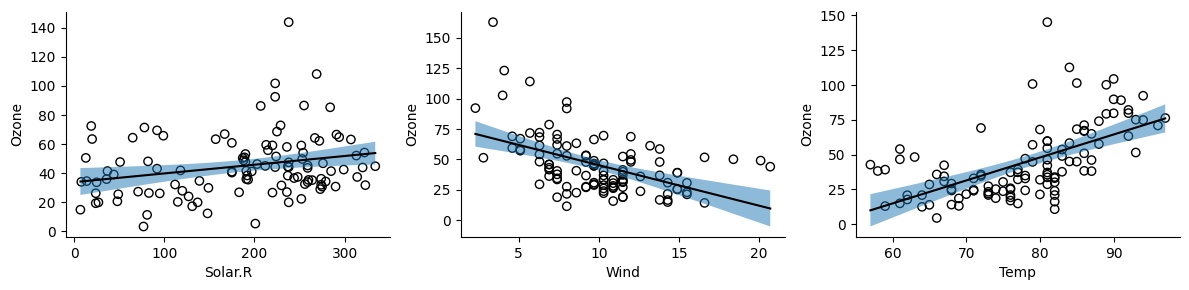

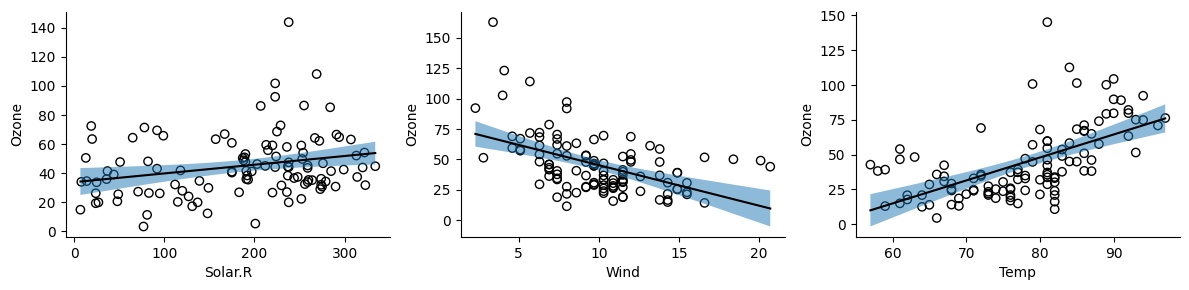

In [33]:
fit.plot_conditional()

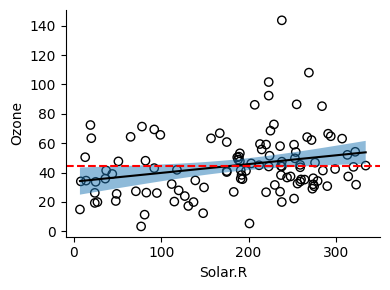

In [34]:
import matplotlib.pyplot as plt

fit.plot_conditional('Solar.R')
plt.axhline(44.5, color='red', ls='--')